In [1]:
# ── NOTEBOOK: REALISTIC DATA SPLITS WITH FULL SEQUENCES ────────────────────
# This creates train/val/test splits with:
# - Full sequence length (986 timesteps) - preserves anomaly patterns
# - Realistic test set (1% anomalies) - matches real-world deployment
# - Balanced validation set (50% anomalies) - for optimal threshold tuning
# - Training set (100% normal) - for unsupervised learning

# ============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================================
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuration
SEQ_LEN = 986  # Full sequence length (minimum timesteps across samples)
TEST_SIZE = 500  # Total test samples
TEST_ANOMALY_RATIO = 0.01  # 1% anomalies in test (realistic)
VAL_ANOMALY_RATIO = 0.5    # 50% anomalies in validation (for tuning)

# Paths
RAW_PATH = Path("voraus-ad-dataset-100hz.parquet")
OUTPUT_DIR = Path("data/realistic_full_sequences")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("REALISTIC DATA SPLITS - FULL SEQUENCES")
print("="*60)
print(f"Sequence length: {SEQ_LEN} timesteps")
print(f"Test size: {TEST_SIZE} samples")
print(f"Test anomaly ratio: {TEST_ANOMALY_RATIO:.0%}")
print(f"Validation anomaly ratio: {VAL_ANOMALY_RATIO:.0%}")
print(f"Output directory: {OUTPUT_DIR}")

REALISTIC DATA SPLITS - FULL SEQUENCES
Sequence length: 986 timesteps
Test size: 500 samples
Test anomaly ratio: 1%
Validation anomaly ratio: 50%
Output directory: data/realistic_full_sequences


In [2]:
# ============================================================================
# CELL 2: LOAD AND EXPLORE RAW DATA
# ============================================================================
print("\n1. LOADING RAW DATA...")
df = pd.read_parquet(RAW_PATH)
print(f"Raw data shape: {df.shape}")

# Identify metadata columns
METADATA_COLS = ['time', 'sample', 'anomaly', 'category', 'setting', 'action', 'active']

# Get all sensor columns
all_sensors = [c for c in df.columns if c not in METADATA_COLS]
print(f"Total sensor columns: {len(all_sensors)}")

# Remove constant sensors (no variance)
constant_sensors = [col for col in all_sensors if df[col].nunique() <= 1]
sensors_to_keep = [col for col in all_sensors if col not in constant_sensors]
print(f"Removed {len(constant_sensors)} constant sensors")
print(f"Keeping {len(sensors_to_keep)} sensors")

# Display first few sensors
print(f"\nFirst 10 sensors: {sensors_to_keep[:10]}")


1. LOADING RAW DATA...
Raw data shape: (2321690, 137)
Total sensor columns: 130
Removed 1 constant sensors
Keeping 129 sensors

First 10 sensors: ['robot_voltage', 'robot_current', 'io_current', 'system_current', 'target_position_1', 'target_velocity_1', 'target_acceleration_1', 'target_torque_1', 'computed_inertia_1', 'computed_torque_1']


In [3]:
# ============================================================================
# CELL 3: CREATE SAMPLE-LEVEL METADATA
# ============================================================================
print("\n2. CREATING SAMPLE-LEVEL METADATA...")

# Aggregate per sample
sample_meta = df.groupby('sample').agg(
    anomaly=('anomaly', 'first'),
    n_timesteps=('time', 'count')
).reset_index()

print(f"Total samples: {len(sample_meta)}")
print(f"  Normal samples: {(~sample_meta['anomaly']).sum()}")
print(f"  Anomaly samples: {sample_meta['anomaly'].sum()}")
print(f"  Current anomaly rate: {sample_meta['anomaly'].mean():.1%}")

# Filter to samples with enough timesteps for full sequence
valid_samples = sample_meta[sample_meta['n_timesteps'] >= SEQ_LEN]
print(f"\nSamples with ≥{SEQ_LEN} timesteps: {len(valid_samples)}/{len(sample_meta)}")

# Separate normal and anomaly
normal_samples = valid_samples[~valid_samples['anomaly']]
anomaly_samples = valid_samples[valid_samples['anomaly']]

print(f"\nValid samples:")
print(f"  Normal: {len(normal_samples)}")
print(f"  Anomaly: {len(anomaly_samples)}")
print(f"  Total: {len(valid_samples)}")


2. CREATING SAMPLE-LEVEL METADATA...
Total samples: 2122
  Normal samples: 1367
  Anomaly samples: 755
  Current anomaly rate: 35.6%

Samples with ≥986 timesteps: 2122/2122

Valid samples:
  Normal: 1367
  Anomaly: 755
  Total: 2122


In [4]:
# ============================================================================
# CELL 4: CREATE REALISTIC TRAIN/VAL/TEST SPLITS
# ============================================================================
print("\n3. CREATING REALISTIC SPLITS...")

# Step 1: Create TEST set (realistic: mostly normal, few anomalies)
n_test_normal = int(TEST_SIZE * (1 - TEST_ANOMALY_RATIO))
n_test_anomaly = TEST_SIZE - n_test_normal

# Ensure we don't request more samples than available
n_test_normal = min(n_test_normal, len(normal_samples))
n_test_anomaly = min(n_test_anomaly, len(anomaly_samples))

test_normal = normal_samples.sample(n=n_test_normal, random_state=RANDOM_STATE)
test_anomaly = anomaly_samples.sample(n=n_test_anomaly, random_state=RANDOM_STATE)
test_samples = pd.concat([test_normal, test_anomaly])

print(f"\nTest set (sample-level):")
print(f"  Normal samples: {len(test_normal)}")
print(f"  Anomaly samples: {len(test_anomaly)}")
print(f"  Total: {len(test_samples)}")
print(f"  Anomaly rate: {len(test_anomaly)/len(test_samples):.2%}")

# Remove test samples from the pool
remaining_normal = normal_samples.drop(test_normal.index)
remaining_anomaly = anomaly_samples.drop(test_anomaly.index)

print(f"\nRemaining after removing test:")
print(f"  Normal: {len(remaining_normal)}")
print(f"  Anomaly: {len(remaining_anomaly)}")

# Step 2: Create VALIDATION set (balanced for threshold tuning)
n_val_anomaly = min(250, len(remaining_anomaly))  # Use up to 250 anomalies
n_val_normal = int(n_val_anomaly * (1 - VAL_ANOMALY_RATIO) / VAL_ANOMALY_RATIO)
n_val_normal = min(n_val_normal, len(remaining_normal))

val_normal = remaining_normal.sample(n=n_val_normal, random_state=RANDOM_STATE)
val_anomaly = remaining_anomaly.sample(n=n_val_anomaly, random_state=RANDOM_STATE)
val_samples = pd.concat([val_normal, val_anomaly])

print(f"\nValidation set (sample-level):")
print(f"  Normal samples: {len(val_normal)}")
print(f"  Anomaly samples: {len(val_anomaly)}")
print(f"  Total: {len(val_samples)}")
print(f"  Anomaly rate: {len(val_anomaly)/len(val_samples):.2%}")

# Remove validation samples from pool
remaining_normal = remaining_normal.drop(val_normal.index)
remaining_anomaly = remaining_anomaly.drop(val_anomaly.index)

# Step 3: Create TRAINING set (all remaining normal samples, NO anomalies)
train_normal = remaining_normal
train_samples = train_normal  # Only normal samples

print(f"\nTraining set (sample-level):")
print(f"  Normal samples: {len(train_normal)}")
print(f"  Anomaly samples: 0")
print(f"  Total: {len(train_samples)}")
print(f"  Anomaly rate: 0%")

# Summary of unused samples
unused_normal = remaining_normal.drop(train_normal.index) if len(train_normal) < len(remaining_normal) else pd.DataFrame()
unused_anomaly = remaining_anomaly

print(f"\nUnused samples (held out):")
print(f"  Normal: {len(unused_normal)}")
print(f"  Anomaly: {len(unused_anomaly)}")


3. CREATING REALISTIC SPLITS...

Test set (sample-level):
  Normal samples: 495
  Anomaly samples: 5
  Total: 500
  Anomaly rate: 1.00%

Remaining after removing test:
  Normal: 872
  Anomaly: 750

Validation set (sample-level):
  Normal samples: 250
  Anomaly samples: 250
  Total: 500
  Anomaly rate: 50.00%

Training set (sample-level):
  Normal samples: 622
  Anomaly samples: 0
  Total: 622
  Anomaly rate: 0%

Unused samples (held out):
  Normal: 0
  Anomaly: 500


In [5]:
# ============================================================================
# CELL 5: LOAD FULL SEQUENCES
# ============================================================================
print("\n4. LOADING FULL SEQUENCES...")

def load_full_sequence(sample_id, df, sensors, seq_len):
    """
    Load the last seq_len timesteps of a sample.
    Uses last timesteps to capture the most recent behavior.
    """
    sample_data = df[df['sample'] == sample_id][sensors].values
    
    if len(sample_data) >= seq_len:
        # Take the last seq_len timesteps
        sequence = sample_data[-seq_len:]
    else:
        # Pad at the beginning if shorter (should not happen due to filtering)
        pad_len = seq_len - len(sample_data)
        sequence = np.vstack([np.zeros((pad_len, len(sensors))), sample_data])
    
    return sequence

def build_sequences(sample_ids, df, sensors, seq_len):
    """Stack sequences into a 3D numpy array."""
    sequences = []
    for sid in sample_ids:
        seq = load_full_sequence(sid, df, sensors, seq_len)
        sequences.append(seq)
    return np.array(sequences)

# Build sequences for each split
X_train_raw = build_sequences(train_samples['sample'], df, sensors_to_keep, SEQ_LEN)
X_val_raw = build_sequences(val_samples['sample'], df, sensors_to_keep, SEQ_LEN)
X_test_raw = build_sequences(test_samples['sample'], df, sensors_to_keep, SEQ_LEN)

# Create labels
y_val = val_samples['anomaly'].astype(int).values
y_test = test_samples['anomaly'].astype(int).values

print(f"\nSequence shapes:")
print(f"  X_train: {X_train_raw.shape} (samples, timesteps, features)")
print(f"  X_val:   {X_val_raw.shape}")
print(f"  X_test:  {X_test_raw.shape}")

print(f"\nLabel distribution:")
print(f"  Validation - Normal: {(y_val==0).sum()}, Anomaly: {(y_val==1).sum()}")
print(f"  Test - Normal: {(y_test==0).sum()}, Anomaly: {(y_test==1).sum()}")
print(f"  Test anomaly rate: {y_test.mean():.2%} ✓ Realistic!")


4. LOADING FULL SEQUENCES...

Sequence shapes:
  X_train: (622, 986, 129) (samples, timesteps, features)
  X_val:   (500, 986, 129)
  X_test:  (500, 986, 129)

Label distribution:
  Validation - Normal: 250, Anomaly: 250
  Test - Normal: 495, Anomaly: 5
  Test anomaly rate: 1.00% ✓ Realistic!


In [6]:
# ============================================================================
# CELL 6: SCALE THE DATA
# ============================================================================
print("\n5. SCALING DATA...")

# Reshape to (N*T, F) for fitting scaler
n_train, T, F = X_train_raw.shape
X_train_flat = X_train_raw.reshape(-1, F)

# Fit scaler on training data ONLY (no leakage)
scaler = StandardScaler()
scaler.fit(X_train_flat)

# Transform all data
X_train = scaler.transform(X_train_flat).reshape(n_train, T, F).astype('float32')

n_val, T, F = X_val_raw.shape
X_val = scaler.transform(X_val_raw.reshape(-1, F)).reshape(n_val, T, F).astype('float32')

n_test, T, F = X_test_raw.shape
X_test = scaler.transform(X_test_raw.reshape(-1, F)).reshape(n_test, T, F).astype('float32')

print(f"Data scaled to {X_train.dtype}")
print(f"Training data - Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"\nFinal scaled shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")


5. SCALING DATA...
Data scaled to float32
Training data - Mean: 0.0000, Std: 1.0000

Final scaled shapes:
  X_train: (622, 986, 129)
  X_val:   (500, 986, 129)
  X_test:  (500, 986, 129)


In [7]:
# ============================================================================
# CELL 7: SAVE PROCESSED DATA
# ============================================================================
print("\n6. SAVING PROCESSED DATA...")

# Save numpy arrays
np.savez_compressed(
    OUTPUT_DIR / "realistic_full_splits.npz",
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_val=y_val,
    y_test=y_test
)

# Save scaler
with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save metadata
train_samples.to_parquet(OUTPUT_DIR / "train_metadata.parquet")
val_samples.to_parquet(OUTPUT_DIR / "val_metadata.parquet")
test_samples.to_parquet(OUTPUT_DIR / "test_metadata.parquet")

# Save configuration
config = {
    'seq_len': SEQ_LEN,
    'n_features': F,
    'n_sensors': len(sensors_to_keep),
    'sensors': sensors_to_keep,
    'train_samples': len(train_samples),
    'val_samples': len(val_samples),
    'test_samples': len(test_samples),
    'train_normal_count': len(train_samples),
    'val_normal_count': len(val_normal),
    'val_anomaly_count': len(val_anomaly),
    'test_normal_count': len(test_normal),
    'test_anomaly_count': len(test_anomaly),
    'test_anomaly_ratio': float(y_test.mean()),
    'val_anomaly_ratio': float(y_val.mean()),
    'random_state': RANDOM_STATE
}

with open(OUTPUT_DIR / "config.pkl", "wb") as f:
    pickle.dump(config, f)

# Save sample IDs for reference
sample_ids = {
    'train': train_samples['sample'].tolist(),
    'val_normal': val_normal['sample'].tolist(),
    'val_anomaly': val_anomaly['sample'].tolist(),
    'test_normal': test_normal['sample'].tolist(),
    'test_anomaly': test_anomaly['sample'].tolist()
}

with open(OUTPUT_DIR / "sample_ids.pkl", "wb") as f:
    pickle.dump(sample_ids, f)

print(f"\n✓ All files saved to {OUTPUT_DIR}")
print(f"  - realistic_full_splits.npz (X_train, X_val, X_test, y_val, y_test)")
print(f"  - scaler.pkl")
print(f"  - *_metadata.parquet")
print(f"  - config.pkl")
print(f"  - sample_ids.pkl")


6. SAVING PROCESSED DATA...

✓ All files saved to data/realistic_full_sequences
  - realistic_full_splits.npz (X_train, X_val, X_test, y_val, y_test)
  - scaler.pkl
  - *_metadata.parquet
  - config.pkl
  - sample_ids.pkl


In [8]:
# ============================================================================
# CELL 7: SAVE PROCESSED DATA
# ============================================================================
print("\n6. SAVING PROCESSED DATA...")

# Save numpy arrays
np.savez_compressed(
    OUTPUT_DIR / "realistic_full_splits.npz",
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_val=y_val,
    y_test=y_test
)

# Save scaler
with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save metadata
train_samples.to_parquet(OUTPUT_DIR / "train_metadata.parquet")
val_samples.to_parquet(OUTPUT_DIR / "val_metadata.parquet")
test_samples.to_parquet(OUTPUT_DIR / "test_metadata.parquet")

# Save configuration
config = {
    'seq_len': SEQ_LEN,
    'n_features': F,
    'n_sensors': len(sensors_to_keep),
    'sensors': sensors_to_keep,
    'train_samples': len(train_samples),
    'val_samples': len(val_samples),
    'test_samples': len(test_samples),
    'train_normal_count': len(train_samples),
    'val_normal_count': len(val_normal),
    'val_anomaly_count': len(val_anomaly),
    'test_normal_count': len(test_normal),
    'test_anomaly_count': len(test_anomaly),
    'test_anomaly_ratio': float(y_test.mean()),
    'val_anomaly_ratio': float(y_val.mean()),
    'random_state': RANDOM_STATE
}

with open(OUTPUT_DIR / "config.pkl", "wb") as f:
    pickle.dump(config, f)

# Save sample IDs for reference
sample_ids = {
    'train': train_samples['sample'].tolist(),
    'val_normal': val_normal['sample'].tolist(),
    'val_anomaly': val_anomaly['sample'].tolist(),
    'test_normal': test_normal['sample'].tolist(),
    'test_anomaly': test_anomaly['sample'].tolist()
}

with open(OUTPUT_DIR / "sample_ids.pkl", "wb") as f:
    pickle.dump(sample_ids, f)

print(f"\n✓ All files saved to {OUTPUT_DIR}")
print(f"  - realistic_full_splits.npz (X_train, X_val, X_test, y_val, y_test)")
print(f"  - scaler.pkl")
print(f"  - *_metadata.parquet")
print(f"  - config.pkl")
print(f"  - sample_ids.pkl")


6. SAVING PROCESSED DATA...

✓ All files saved to data/realistic_full_sequences
  - realistic_full_splits.npz (X_train, X_val, X_test, y_val, y_test)
  - scaler.pkl
  - *_metadata.parquet
  - config.pkl
  - sample_ids.pkl



8. VISUALIZING DATA SPLITS...


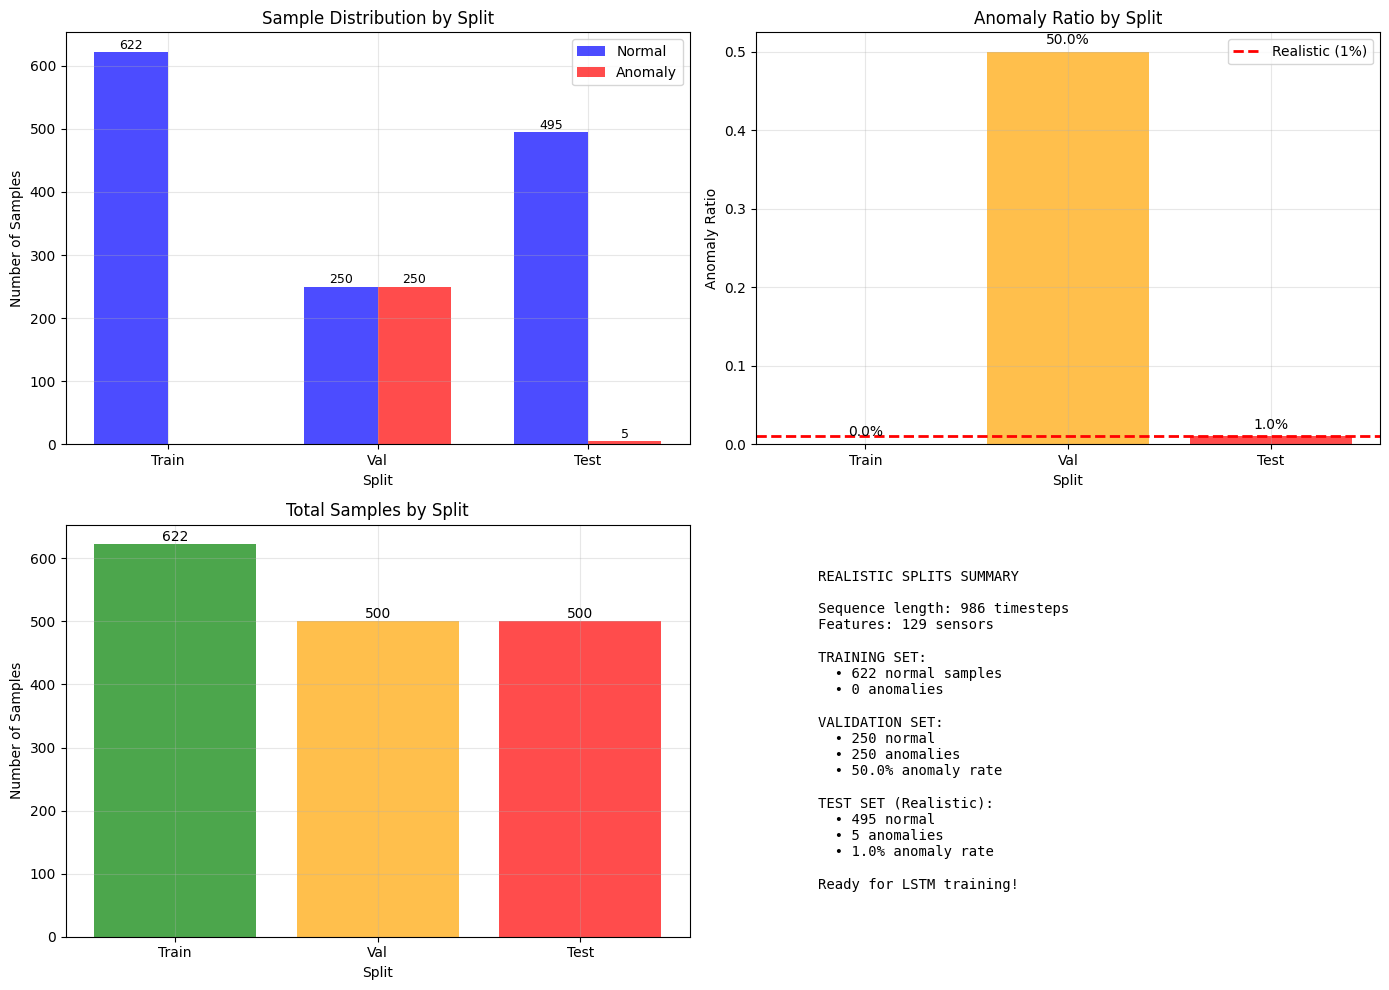

✓ Visualization saved to data/realistic_full_sequences/split_visualization.png


In [9]:
# ============================================================================
# CELL 9: VISUALIZE SPLITS
# ============================================================================
print("\n8. VISUALIZING DATA SPLITS...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sample distribution by split
split_names = ['Train', 'Val', 'Test']
normal_counts = [
    len(train_samples),
    len(val_normal),
    len(test_normal)
]
anomaly_counts = [
    0,
    len(val_anomaly),
    len(test_anomaly)
]

x = np.arange(len(split_names))
width = 0.35

axes[0,0].bar(x - width/2, normal_counts, width, label='Normal', color='blue', alpha=0.7)
axes[0,0].bar(x + width/2, anomaly_counts, width, label='Anomaly', color='red', alpha=0.7)
axes[0,0].set_xlabel('Split')
axes[0,0].set_ylabel('Number of Samples')
axes[0,0].set_title('Sample Distribution by Split')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(split_names)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Add value labels
for i, (n, a) in enumerate(zip(normal_counts, anomaly_counts)):
    axes[0,0].text(i - width/2, n + 5, str(n), ha='center', fontsize=9)
    if a > 0:
        axes[0,0].text(i + width/2, a + 5, str(a), ha='center', fontsize=9)

# Plot 2: Anomaly ratio by split
anomaly_ratios = [0, y_val.mean(), y_test.mean()]
colors = ['green', 'orange', 'red']
bars = axes[0,1].bar(split_names, anomaly_ratios, color=colors, alpha=0.7)
axes[0,1].set_xlabel('Split')
axes[0,1].set_ylabel('Anomaly Ratio')
axes[0,1].set_title('Anomaly Ratio by Split')
axes[0,1].axhline(y=0.01, color='red', linestyle='--', linewidth=2, label='Realistic (1%)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Add value labels
for bar, ratio in zip(bars, anomaly_ratios):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{ratio:.1%}', ha='center', fontsize=10)

# Plot 3: Sample counts comparison (bar chart)
sample_counts = [len(train_samples), len(val_samples), len(test_samples)]
axes[1,0].bar(split_names, sample_counts, color=['green', 'orange', 'red'], alpha=0.7)
axes[1,0].set_xlabel('Split')
axes[1,0].set_ylabel('Number of Samples')
axes[1,0].set_title('Total Samples by Split')
axes[1,0].grid(True, alpha=0.3)
for i, v in enumerate(sample_counts):
    axes[1,0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Plot 4: Summary text
summary_text = f"REALISTIC SPLITS SUMMARY\n\n"
summary_text += f"Sequence length: {SEQ_LEN} timesteps\n"
summary_text += f"Features: {F} sensors\n\n"
summary_text += f"TRAINING SET:\n"
summary_text += f"  • {len(train_samples)} normal samples\n"
summary_text += f"  • 0 anomalies\n\n"
summary_text += f"VALIDATION SET:\n"
summary_text += f"  • {len(val_normal)} normal\n"
summary_text += f"  • {len(val_anomaly)} anomalies\n"
summary_text += f"  • {y_val.mean():.1%} anomaly rate\n\n"
summary_text += f"TEST SET (Realistic):\n"
summary_text += f"  • {len(test_normal)} normal\n"
summary_text += f"  • {len(test_anomaly)} anomalies\n"
summary_text += f"  • {y_test.mean():.1%} anomaly rate\n\n"
summary_text += f"Ready for LSTM training!"

axes[1,1].text(0.1, 0.5, summary_text, transform=axes[1,1].transAxes,
               fontsize=10, verticalalignment='center', fontfamily='monospace')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_visualization.png', dpi=150)
plt.show()

print(f"✓ Visualization saved to {OUTPUT_DIR}/split_visualization.png")